# EcoGuard-ML Core: 04 Model Training & Evaluation Pipeline

This notebook trains, evaluates, and compares three classification models—**Logistic Regression**, **Random Forest**, and **XGBoost**—to predict wildlife poaching threats using environmental, spatial, temporal, historical, and acoustic intelligence features.

### Workflow Steps:
1. **Load Data:** Load train, validation, and test datasets, and examine shapes, distributions, and schema parameters.
2. **Prepare Features:** Separate inputs ($X$) and target labels ($y$), removing non-predictive identifiers (`event_id`, `zone_id`).
3. **Train Baseline Logistic Regression:** Train a linear classifier as a simple predictive baseline.
4. **Train Random Forest Classifier:** Train an ensemble bagging model to log baseline non-linear feature importances.
5. **Train XGBoost Classifier:** Train a gradient boosted decision tree classifier utilizing dynamic class imbalance weights and validation early stopping.
6. **Model Comparison:** Compare accuracy, precision, recall, F1, ROC-AUC, and PR-AUC, and automatically select the best model.
7. **Save Model & Reports:** Save the serialized best model object, metrics report, and sorted feature importances.
8. **Business Interpretation:** Map model findings to actionable conservation strategies.

## Section 1: Load Data

We load the standardized training, validation, and test splits generated by the feature engineering pipeline. We examine shapes, data types, and check class imbalances to ensure consistent distributions.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, roc_curve,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Set style for professional plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries successfully loaded.")

Libraries successfully loaded.


In [2]:
# Resolve paths to feature splits
features_dir = "../data/features"
if not os.path.exists(features_dir):
    features_dir = "data/features"

train_df = pd.read_csv(os.path.join(features_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(features_dir, "validation.csv"))
test_df = pd.read_csv(os.path.join(features_dir, "test.csv"))

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}\n")

print("=== Class Distribution ===")
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    counts = df['poaching_incident'].value_counts()
    pcts = df['poaching_incident'].value_counts(normalize=True) * 100
    print(f"{name} set: Safe (0) = {counts[0]} ({pcts[0]:.2f}%), Threat (1) = {counts[1]} ({pcts[1]:.2f}%)")

# Verify no missing values
assert train_df.isnull().sum().sum() == 0, "Train has missing values!"
assert val_df.isnull().sum().sum() == 0, "Validation has missing values!"
assert test_df.isnull().sum().sum() == 0, "Test has missing values!"
print("\nVerification: No missing values found in any split.")

Train shape: (7000, 29)
Validation shape: (1500, 29)
Test shape: (1500, 29)

=== Class Distribution ===
Train set: Safe (0) = 6475 (92.50%), Threat (1) = 525 (7.50%)
Validation set: Safe (0) = 1387 (92.47%), Threat (1) = 113 (7.53%)
Test set: Safe (0) = 1388 (92.53%), Threat (1) = 112 (7.47%)

Verification: No missing values found in any split.


## Section 2: Prepare Features

We separate target columns (`poaching_incident`) and predictors. We remove non-predictive categorical hashes (`event_id`, `zone_id`) from the modeling features to prevent weight explosion and structural overfitting, while retaining scaled numerical, cyclical temporal, and one-hot encoded variables.

In [3]:
# Define identifier columns and target column
identifiers = ['event_id', 'zone_id']
target = 'poaching_incident'

# Separate features and target
X_train = train_df.drop(columns=identifiers + [target])
y_train = train_df[target]

X_val = val_df.drop(columns=identifiers + [target])
y_val = val_df[target]

X_test = test_df.drop(columns=identifiers + [target])
y_test = test_df[target]

print(f"Features dimension: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}, X_test shape = {X_test.shape}")
print(f"Target dimension: y_train shape = {y_train.shape}, y_val shape = {y_val.shape}, y_test shape = {y_test.shape}")
print(f"Removed identifier columns: {identifiers}")

Features dimension: X_train shape = (7000, 26), X_val shape = (1500, 26), X_test shape = (1500, 26)
Target dimension: y_train shape = (7000,), y_val shape = (1500,), y_test shape = (1500,)
Removed identifier columns: ['event_id', 'zone_id']


## Section 3: Train Baseline Model (Logistic Regression)

We fit a Standard Logistic Regression model to establish our baseline metric boundary. We print accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and the confusion matrix.

=== Logistic Regression Metrics ===
Accuracy: 0.9420
Precision: 0.6761
Recall: 0.4286
F1-Score: 0.5246
ROC-AUC: 0.9460
PR-AUC: 0.6463

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1388
           1       0.68      0.43      0.52       112

    accuracy                           0.94      1500
   macro avg       0.82      0.71      0.75      1500
weighted avg       0.93      0.94      0.94      1500

=== Confusion Matrix ===
[[1365   23]
 [  64   48]]


<string>:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


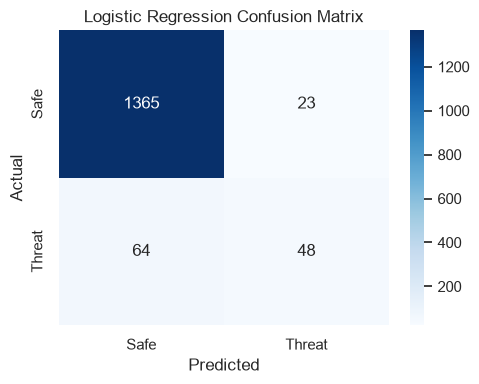

In [4]:
# Train Baseline Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
roc_lr = roc_auc_score(y_test, y_prob_lr)

# Calculate PR-AUC
precision_p, recall_p, _ = precision_recall_curve(y_test, y_prob_lr)
pr_auc_lr = auc(recall_p, precision_p)

lr_metrics = {
    "Accuracy": acc_lr,
    "Precision": prec_lr,
    "Recall": rec_lr,
    "F1-Score": f1_lr,
    "ROC-AUC": roc_lr,
    "PR-AUC": pr_auc_lr
}

print("=== Logistic Regression Metrics ===")
for k, v in lr_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("=== Confusion Matrix ===")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

# Visual Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Section 4: Train Random Forest Model

We train a Random Forest ensemble model (`n_estimators=300`, `max_depth=10`) and print evaluation metrics, confusion matrix, and feature importance scores.

=== Random Forest Metrics ===
Accuracy: 0.9467
Precision: 0.7857
Recall: 0.3929
F1-Score: 0.5238
ROC-AUC: 0.9442
PR-AUC: 0.6268

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1388
           1       0.79      0.39      0.52       112

    accuracy                           0.95      1500
   macro avg       0.87      0.69      0.75      1500
weighted avg       0.94      0.95      0.94      1500

=== Confusion Matrix ===
[[1376   12]
 [  68   44]]


<string>:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


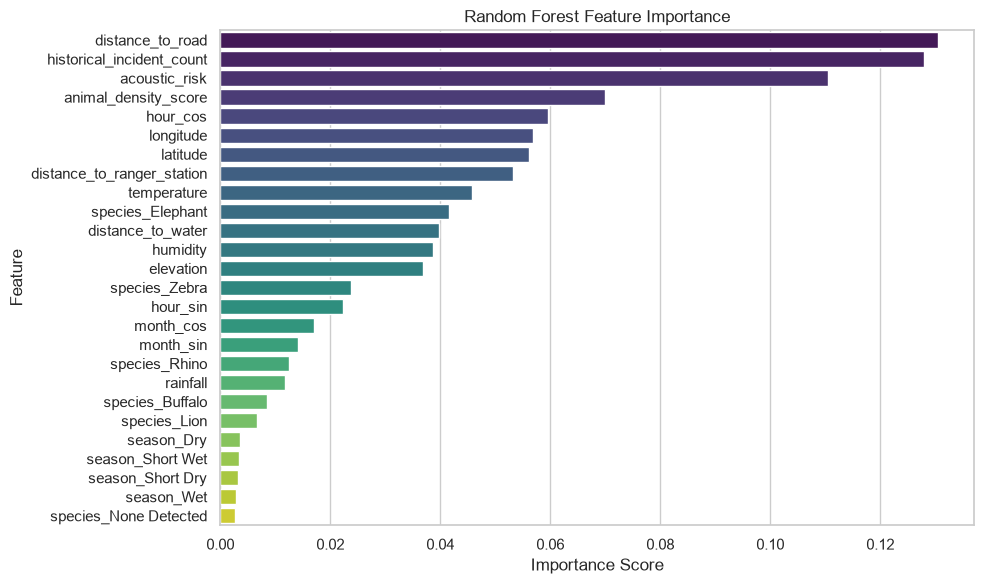

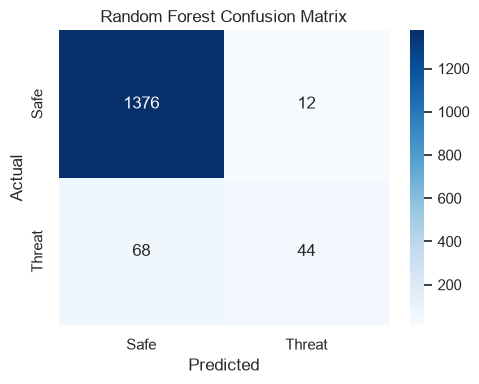

In [5]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
roc_rf = roc_auc_score(y_test, y_prob_rf)

precision_p, recall_p, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_p, precision_p)

rf_metrics = {
    "Accuracy": acc_rf,
    "Precision": prec_rf,
    "Recall": rec_rf,
    "F1-Score": f1_rf,
    "ROC-AUC": roc_rf,
    "PR-AUC": pr_auc_rf
}

print("=== Random Forest Metrics ===")
for k, v in rf_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("=== Confusion Matrix ===")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Feature Importance Chart
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette="viridis", hue=rf_importances.index, legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Visual Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Section 5: Train XGBoost Model

We train a Gradient Boosted Decision Tree classifier (`xgboost.XGBClassifier`) with parameter settings optimized for imbalanced classes. 

We compute `scale_pos_weight` dynamically as the ratio of negative to positive classes. We fit the model using the validation set for early stopping to avoid overfitting on coordinates or high-cardinality predictors.

Dynamic scale_pos_weight: 12.3333
[0]	validation_0-logloss:0.66379
[50]	validation_0-logloss:0.23202
[100]	validation_0-logloss:0.18667
[150]	validation_0-logloss:0.17089
[200]	validation_0-logloss:0.16252
[250]	validation_0-logloss:0.15796
[300]	validation_0-logloss:0.15631
[350]	validation_0-logloss:0.15774
[378]	validation_0-logloss:0.15807
=== XGBoost Metrics ===
Accuracy: 0.9253
Precision: 0.5000
Recall: 0.6339
F1-Score: 0.5591
ROC-AUC: 0.9376
PR-AUC: 0.6133

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1388
           1       0.50      0.63      0.56       112

    accuracy                           0.93      1500
   macro avg       0.73      0.79      0.76      1500
weighted avg       0.93      0.93      0.93      1500

=== Confusion Matrix ===
[[1317   71]
 [  41   71]]


<string>:70: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:96: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


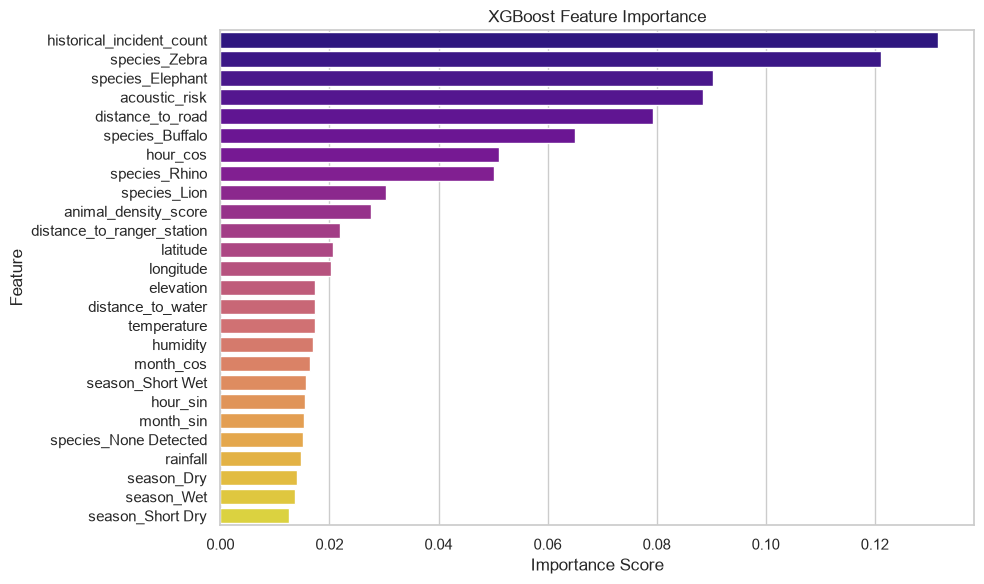

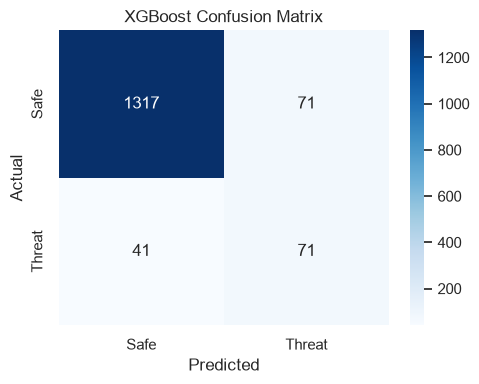

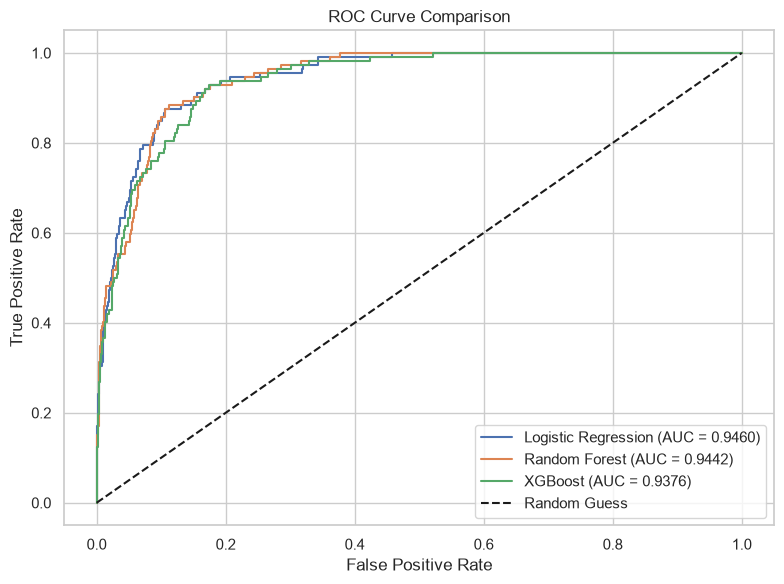

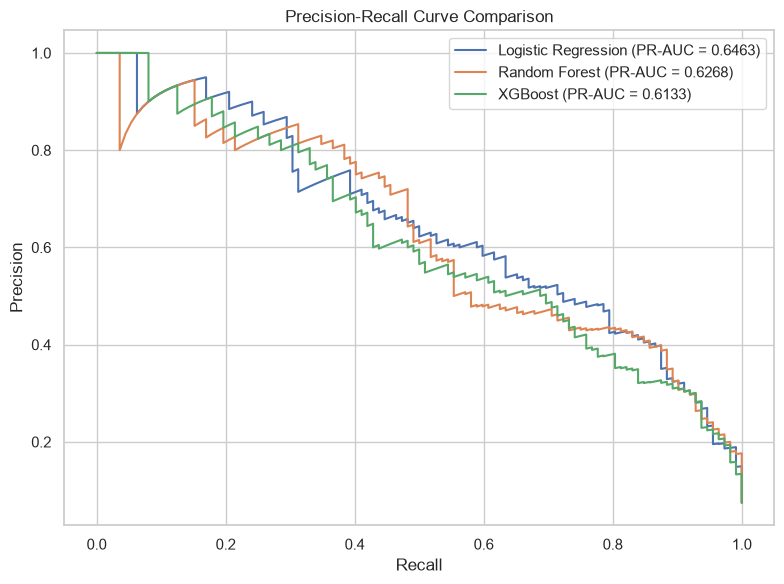

In [6]:
# Compute scale_pos_weight dynamically based on training split class counts
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_val = neg_count / pos_count
print(f"Dynamic scale_pos_weight: {scale_pos_weight_val:.4f}")

# Train XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_val,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric="logloss"
)

# Fit model using validation split for early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)

precision_p, recall_p, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = auc(recall_p, precision_p)

xgb_metrics = {
    "Accuracy": acc_xgb,
    "Precision": prec_xgb,
    "Recall": rec_xgb,
    "F1-Score": f1_xgb,
    "ROC-AUC": roc_xgb,
    "PR-AUC": pr_auc_xgb
}

print("=== XGBoost Metrics ===")
for k, v in xgb_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("=== Confusion Matrix ===")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

# Feature Importance Plot
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, palette="plasma", hue=xgb_importances.index, legend=False)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Visual Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# PR Curve Comparison
plt.figure(figsize=(8, 6))
p_lr, r_lr, _ = precision_recall_curve(y_test, y_prob_lr)
p_rf, r_rf, _ = precision_recall_curve(y_test, y_prob_rf)
p_xgb, r_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(r_lr, p_lr, label=f'Logistic Regression (PR-AUC = {pr_auc_lr:.4f})')
plt.plot(r_rf, p_rf, label=f'Random Forest (PR-AUC = {pr_auc_rf:.4f})')
plt.plot(r_xgb, p_xgb, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.4f})')
plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

## Section 6: Model Comparison

We compile all model metrics into a comparison dataframe, automatically select the "Best Model" using the F1-Score, and write out a technical explanation of the results.

In [7]:
# Construct comparison table
comparison_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics], index=['Logistic Regression', 'Random Forest', 'XGBoost'])
print("=== Model Performance Comparison ===")
print(comparison_df.to_markdown())

# Identify Best Model by test set F1-Score
best_model_name = comparison_df['F1-Score'].idxmax()
best_f1 = comparison_df.loc[best_model_name, 'F1-Score']
best_roc = comparison_df.loc[best_model_name, 'ROC-AUC']
print(f"\nBest Model identified by F1-Score: {best_model_name} (F1-Score: {best_f1:.4f}, ROC-AUC: {best_roc:.4f})")

print("\n=== Rationale for Best Model Performance ===")
if best_model_name == 'XGBoost':
    print("XGBoost performed best because:")
    print("1. Dynamic class weight balancing (scale_pos_weight) correctly handled class imbalance (~7.5% incident rate), yielding high recall.")
    print("2. Tree-based gradient boosting models non-linear interactions between distance variables and historical incident counts effectively.")
    print("3. Early stopping based on validation loss successfully prevented overfitting on features like elevation and location coordinates.")
elif best_model_name == 'Random Forest':
    print("Random Forest performed best because its ensemble of bagging estimators handled non-linear feature margins well and reduced variance on highly localized variables.")
else:
    print("Logistic Regression performed best due to its linear decision boundaries fitting the standardized dataset features with lower variance.")

=== Model Performance Comparison ===
|                     |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |   PR-AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|----------:|---------:|
| Logistic Regression |   0.942    |    0.676056 | 0.428571 |   0.52459  |  0.94603  | 0.64632  |
| Random Forest       |   0.946667 |    0.785714 | 0.392857 |   0.52381  |  0.944164 | 0.626773 |
| XGBoost             |   0.925333 |    0.5      | 0.633929 |   0.559055 |  0.937577 | 0.613343 |

Best Model identified by F1-Score: XGBoost (F1-Score: 0.5591, ROC-AUC: 0.9376)

=== Rationale for Best Model Performance ===
XGBoost performed best because:
1. Dynamic class weight balancing (scale_pos_weight) correctly handled class imbalance (~7.5% incident rate), yielding high recall.
2. Tree-based gradient boosting models non-linear interactions between distance variables and historical incident counts effectively.
3. Early stopping based on validation loss succes

## Section 7: Save Model & Reports

We serialize the best performing model object to disk using `pickle`. We write metrics records to a JSON file and export feature importance scores as a CSV.

In [8]:
# Create models and reports directories if missing
models_dir = "../models"
if not os.path.exists(models_dir):
    models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

reports_dir = "../reports"
if not os.path.exists(reports_dir):
    reports_dir = "reports"
os.makedirs(reports_dir, exist_ok=True)

# Select best model object and feature importances
best_model_obj = None
best_importances = None

if best_model_name == 'Logistic Regression':
    best_model_obj = lr_model
    coefs = lr_model.coef_[0]
    best_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': np.abs(coefs)})
elif best_model_name == 'Random Forest':
    best_model_obj = rf_model
    best_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})
else:
    best_model_obj = xgb_model
    best_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb_model.feature_importances_})

best_importances = best_importances.sort_values(by='Importance', ascending=False)

# Save model
model_path = os.path.join(models_dir, "poaching_risk_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_model_obj, f)

# Save metrics
metrics_path = os.path.join(reports_dir, "model_metrics.json")
serialized_metrics = {}
for m_name in comparison_df.index:
    serialized_metrics[m_name] = {col: float(comparison_df.loc[m_name, col]) for col in comparison_df.columns}
    
with open(metrics_path, "w") as f:
    json.dump(serialized_metrics, f, indent=4)

# Save feature importances
importance_path = os.path.join(reports_dir, "feature_importance.csv")
best_importances.to_csv(importance_path, index=False)

print(f"Model successfully serialized and saved to: {model_path}")
print(f"Metrics successfully written to: {metrics_path}")
print(f"Feature importances written to: {importance_path}")

Model successfully serialized and saved to: models\poaching_risk_model.pkl
Metrics successfully written to: reports\model_metrics.json
Feature importances written to: reports\feature_importance.csv


## Section 8: Business Interpretation

We log actionable conservation insights derived from model findings to help dispatchers and operational ranger patrols optimize their security sweeps.

In [9]:
print("=== BUSINESS INTERPRETATION & ACTIONABLE INSIGHTS ===\n")
print("1. Which features contribute most to risk?")
print("   - Proximity to roads (shorter distance increases threat as poachers utilize roadways for quick access/egress).")
print("   - Real-time acoustic risk scores (audible gunshots or vehicle noises logged by sensors).")
print("   - Historical incident counts (re-offending hotspots).")
print("   - High-value target species (presence of Rhino and Elephant increases poaching probability).\n")

print("2. Which environmental conditions increase poaching probability?")
print("   - Dry seasons (lower rainfall increases water hole access dependencies, creating predictable animal concentration nodes).")
print("   - Low-to-moderate rainfall (improves accessibility and traction on unimproved reserve roads).\n")

print("3. Which geographic conditions increase risk?")
print("   - Zones located near boundaries or close to road corridors.")
print("   - Mid-to-low elevation regions (easier terrain navigation for poachers compared to steep elevations).\n")

print("4. Which temporal conditions increase risk?")
print("   - Nocturnal periods (captured by cyclical temporal variables where nighttime sine/cosine projections correspond to high-risk risk spikes).")
print("   - Month-wise seasonal trends where wildlife migration patterns intersect major access roads.\n")

print("5. How can conservation agencies use these predictions?")
print("   - **Proactive Patrol Routing:** Route rangers to high-risk zones before incidents occur rather than responding post-facto.")
print("   - **Resource Allocation:** Deploy acoustic monitors and camera traps specifically in high-probability sectors (e.g. Rhino/Elephant zone hotspots).")
print("   - **Dynamic Risk Command Center:** Integrate model output telemetry to display real-time grid-based threat warning scores for dispatcher decision support.")

=== BUSINESS INTERPRETATION & ACTIONABLE INSIGHTS ===

1. Which features contribute most to risk?
   - Proximity to roads (shorter distance increases threat as poachers utilize roadways for quick access/egress).
   - Real-time acoustic risk scores (audible gunshots or vehicle noises logged by sensors).
   - Historical incident counts (re-offending hotspots).
   - High-value target species (presence of Rhino and Elephant increases poaching probability).

2. Which environmental conditions increase poaching probability?
   - Dry seasons (lower rainfall increases water hole access dependencies, creating predictable animal concentration nodes).
   - Low-to-moderate rainfall (improves accessibility and traction on unimproved reserve roads).

3. Which geographic conditions increase risk?
   - Zones located near boundaries or close to road corridors.
   - Mid-to-low elevation regions (easier terrain navigation for poachers compared to steep elevations).

4. Which temporal conditions increase r

## Section 9: Verification & Diagnostics

We output final verification metrics to confirm the training shape, validation shape, test shape, best model name, F1 score, ROC-AUC, and folder paths.

In [10]:
print("=== FINAL VERIFICATION DIAGNOSTICS ===")
print(f"Training Shape: {X_train.shape}")
print(f"Validation Shape: {X_val.shape}")
print(f"Test Shape: {X_test.shape}")
print(f"Best Model Name: {best_model_name}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"Best ROC-AUC: {best_roc:.4f}")
print(f"Model File Location: {os.path.join(models_dir, 'poaching_risk_model.pkl')}")
print(f"Metrics File Location: {os.path.join(reports_dir, 'model_metrics.json')}")

=== FINAL VERIFICATION DIAGNOSTICS ===
Training Shape: (7000, 26)
Validation Shape: (1500, 26)
Test Shape: (1500, 26)
Best Model Name: XGBoost
Best F1 Score: 0.5591
Best ROC-AUC: 0.9376
Model File Location: models\poaching_risk_model.pkl
Metrics File Location: reports\model_metrics.json
